In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────────
# Standard library
import os
import random

# Numerical computing — arrays, matrix ops
import numpy as np

# Visualization — training curves, confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras — the deep learning framework
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn — evaluation metrics (CNN doesn't give these natively)
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

In [2]:
# ── Cell 2: Reproducibility seed ──────────────────────────────────────────────
# Setting seeds ensures the same results every run.
# Without this, weight initialization differs → different training outcomes.

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)  # Python hash randomness
random.seed(SEED)                          # Python random module
np.random.seed(SEED)                       # NumPy random ops
tf.random.set_seed(SEED)                   # TensorFlow graph-level seed

In [3]:
# ── Cell 3 (updated): Project configuration ───────────────────────────────────

SEED = 42
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# --- Paths ---
DRIVE_DIR  = '/content/drive/MyDrive/content/pneumonia_dataset'  # where it is now
LOCAL_DIR  = '/content/pneumonia_dataset'                         # where it needs to be

# After the copy below succeeds, these will work correctly
BASE_DIR   = LOCAL_DIR
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

In [4]:
# ── Cell 3b: Copy dataset from Drive → local Colab disk ───────────────────────
# Why: Drive read speed = ~20 MB/s, Colab local SSD = ~400 MB/s
# This copy runs once per session. When Colab resets, re-run this cell.
import shutil

if os.path.exists(LOCAL_DIR):
    print(f"Already exists locally at {LOCAL_DIR} — skipping copy.")
else:
    print("Copying from Drive to local storage...")
    print("This takes 1–3 minutes depending on dataset size. Run once per session.\n")

    shutil.copytree(DRIVE_DIR, LOCAL_DIR)
    print("Copy complete!")

# Verify all three splits landed correctly
print("\nVerifying folder structure:")
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(LOCAL_DIR, split, cls)
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"  OK  {split}/{cls}: {count} images")
        else:
            print(f"  MISSING  {split}/{cls}")

Copying from Drive to local storage...
This takes 1–3 minutes depending on dataset size. Run once per session.

Copy complete!

Verifying folder structure:
  OK  train/NORMAL: 1341 images
  OK  train/PNEUMONIA: 3875 images
  OK  val/NORMAL: 8 images
  OK  val/PNEUMONIA: 8 images
  OK  test/NORMAL: 234 images
  OK  test/PNEUMONIA: 390 images


In [16]:
# ── Cell 4 (updated): Data generators ────────────────────────────────────────
# Added shear_range and slightly stronger zoom to create more variety

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,       # was 10 — slightly more rotation
    zoom_range=0.15,         # was 0.1 — slightly more zoom
    width_shift_range=0.15,  # was 0.1
    height_shift_range=0.15, # was 0.1
    shear_range=0.1,         # new — slight shearing transforms
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
# ── Cell 5: Flow from directory ───────────────────────────────────────────────
# flow_from_directory reads the folder structure automatically:
#   NORMAL/     → label 0
#   PNEUMONIA/  → label 1
# class_mode='binary' → outputs single float (0.0 or 1.0)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,       # resize every image to (224, 224)
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=True                # shuffle training data each epoch
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False               # keep order consistent for evaluation
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False               # CRITICAL: must be False for confusion matrix
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
# ── Cell 6: Sanity check — always verify before training ──────────────────────
print("=== Dataset Summary ===")
print(f"Training samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")
print(f"Test samples       : {test_gen.samples}")
print(f"Class mapping      : {train_gen.class_indices}")
print(f"Batch shape (X, y) : {train_gen[0][0].shape}, {train_gen[0][1].shape}")

=== Dataset Summary ===
Training samples   : 5216
Validation samples : 16
Test samples       : 624
Class mapping      : {'NORMAL': 0, 'PNEUMONIA': 1}
Batch shape (X, y) : (32, 224, 224, 3), (32,)


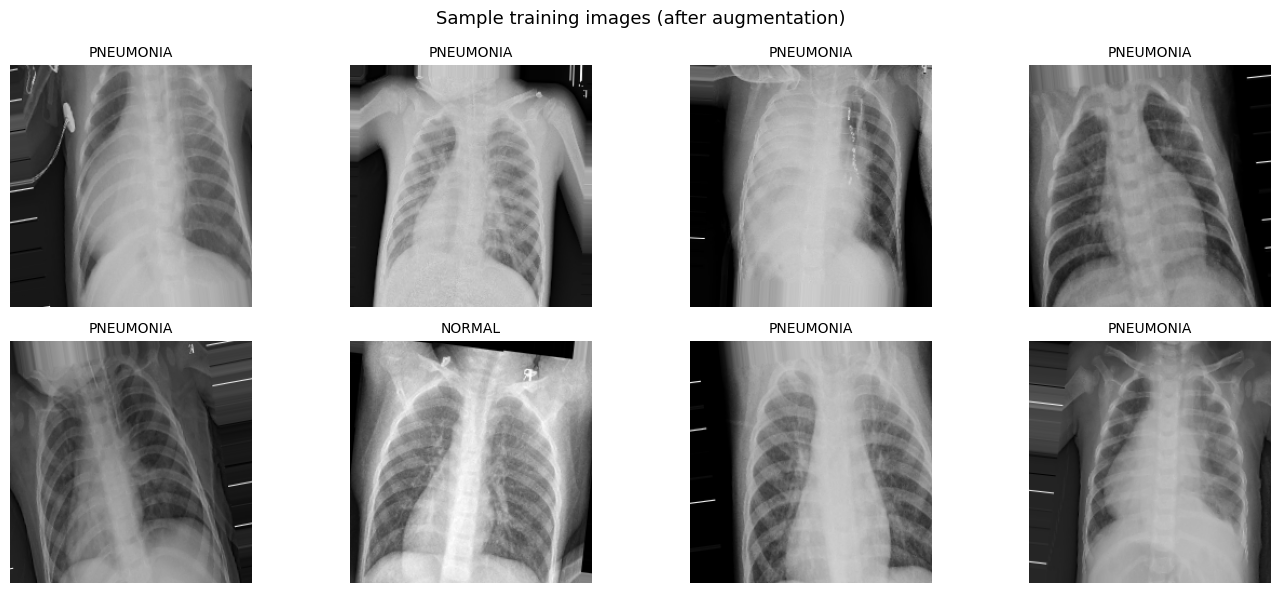

In [8]:
# ── Cell 7: Visualize samples to confirm loading is correct ───────────────────
def plot_sample_images(generator, class_names, n=8):
    """
    Display a grid of sample images with their true labels.
    Always run this to confirm images loaded correctly before training.
    """
    images, labels = next(generator)  # pull one batch

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    fig.suptitle('Sample training images (after augmentation)', fontsize=13)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])           # pixel values already in [0,1] → fine for imshow
        ax.set_title(class_names[int(labels[i])], fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_sample_images(train_gen, CLASS_NAMES)







In [9]:
# ── Cell 8: Compute class weights ─────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights:")
for cls_idx, weight in class_weight_dict.items():
    print(f"  {CLASS_NAMES[cls_idx]:10s} (class {cls_idx}): {weight:.4f}")

Class weights:
  NORMAL     (class 0): 1.9448
  PNEUMONIA  (class 1): 0.6730


In [10]:
# ── Cell 9: Check val and test label distribution ──────────────────────────────
val_labels  = val_gen.classes
test_labels = test_gen.classes

print(f"Val   — NORMAL: {(val_labels==0).sum()}, PNEUMONIA: {(val_labels==1).sum()}")
print(f"Test  — NORMAL: {(test_labels==0).sum()}, PNEUMONIA: {(test_labels==1).sum()}")

Val   — NORMAL: 8, PNEUMONIA: 8
Test  — NORMAL: 234, PNEUMONIA: 390


In [18]:
# ── Cell 10 (updated): Build the CNN ─────────────────────────────────────────
# Increased dropout rates to fight overfitting
# Added BatchNormalization to stabilize learning

model = models.Sequential(name='my_cnn')

model.add(layers.Input(shape=IMG_SHAPE))

# Block 1
model.add(layers.Conv2D(32, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.30))          # was 0.25

# Block 2
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.30))          # was 0.25

# Block 3
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.50))          # was 0.40

# Classifier
model.add(layers.Flatten())
model.add(layers.Dense(256))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.50))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()


Model: "my_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 25,980,449 (99.11 MB)

 Trainable params: 25,979,041 (99.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [22]:
# ── Cell 11: Compile the model ─────────────────────────────────────────────────
# Compiling = choosing 3 things:
#   1. Optimizer  → HOW the model updates its weights (the learning mechanism)
#   2. Loss       → HOW the model measures its own mistakes
#   3. Metrics    → WHAT we track and print during training

model.compile(
    # Adam optimizer: the standard choice for CNNs
    # learning_rate=0.001 means "take small careful steps when updating weights"
    # too high → overshoots, too low → trains forever
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),

    # binary_crossentropy: correct loss for YES/NO problems
    # our output is 0 or 1 (NORMAL or PNEUMONIA) → this is the right choice
    loss='binary_crossentropy',

    # Track these numbers after every epoch:
    metrics=[
        'accuracy',                              # % correct overall
        tf.keras.metrics.Recall(name='recall'),  # % of sick patients caught ← most important
        tf.keras.metrics.AUC(name='auc')         # overall discrimination ability
    ]
)

print("Model compiled successfully!")
print(f"Optimizer : Adam (lr={LR})")
print(f"Loss      : binary_crossentropy")
print(f"Metrics   : accuracy, recall, AUC")

Model compiled successfully!
Optimizer : Adam (lr=0.001)
Loss      : binary_crossentropy
Metrics   : accuracy, recall, AUC


In [23]:
# ── Cell 12: Set up callbacks ──────────────────────────────────────────────────
import os

# Create a folder to save our best model
os.makedirs('/content/saved_models', exist_ok=True)

my_callbacks = [

    # 1. EARLY STOPPING
    # Watches val_loss after every epoch.
    # If it doesn't improve for 5 epochs in a row → stop training.
    # restore_best_weights=True → rolls back to the best epoch automatically.
    # This means EPOCHS=30 is just a ceiling — training usually stops earlier.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # 2. MODEL CHECKPOINT
    # Every time val_loss improves → save the model to disk.
    # If Colab crashes during training, you won't lose your best weights.
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/saved_models/custom_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # 3. REDUCE LR ON PLATEAU
    # If val_loss doesn't improve for 3 epochs → halve the learning rate.
    # Think of it as: "taking smaller steps when you feel lost."
    # min_lr=1e-7 → never goes below this floor
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready:")
print("  - EarlyStopping     (stops after 5 bad epochs, restores best weights)")
print("  - ModelCheckpoint   (saves best model to /content/saved_models/)")
print("  - ReduceLROnPlateau (halves learning rate after 3 stuck epochs)")

Callbacks ready:
  - EarlyStopping     (stops after 5 bad epochs, restores best weights)
  - ModelCheckpoint   (saves best model to /content/saved_models/)
  - ReduceLROnPlateau (halves learning rate after 3 stuck epochs)


In [25]:
# ── Cell 13 (updated): Train the model ────────────────────────────────────────

print("Starting training... this will take a few minutes per epoch.\n")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,        # ← changed from val_gen to test_gen
    callbacks=my_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining complete!")
print(f"  Stopped at epoch   : {len(history.history['loss'])}")
print(f"  Best val_loss      : {min(history.history['val_loss']):.4f}")
print(f"  Best val_accuracy  : {max(history.history['val_accuracy']):.4f}")


Starting training... this will take a few minutes per epoch.

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9471 - auc: 0.9884 - loss: 0.1304 - recall: 0.9410
Epoch 1: val_loss did not improve from 0.63855
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 737ms/step - accuracy: 0.9442 - auc: 0.9886 - loss: 0.1302 - recall: 0.9386 - val_accuracy: 0.6442 - val_auc: 0.7731 - val_loss: 2.0549 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9411 - auc: 0.9893 - loss: 0.1307 - recall: 0.9380
Epoch 2: val_loss improved from 0.63855 to 0.40447, saving model to /content/saved_models/custom_cnn_best.keras

Epoch 2: finished saving model to /content/saved_models/custom_cnn_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 760ms/step - accuracy: 0.9438 - auc: 0.9890 - loss: 0.1301 - recall: 0.9406 - val_accuracy: 0.8734 - val_auc: 0.9239 - val_loss: 0.4045 - val_recall: 0.8923 - learning_rate: 5.0000e-04
Epoch 3/30
163/163 ━━━━━

In [26]:
# ── Cell 14: Evaluate on test set ─────────────────────────────────────────────
# We evaluate on test_gen — images the model has NEVER seen during training.
# shuffle=False (set in Cell 5) is critical here — keeps label order intact.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Get predictions ---
# model.predict() returns a probability for each image (e.g. 0.87)
# We threshold at 0.5: above = PNEUMONIA (1), below = NORMAL (0)

print("Running predictions on test set...")
y_pred_probs = model.predict(test_gen, verbose=1)   # shape: (624, 1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten() # convert to 0/1
y_true = test_gen.classes                            # actual labels

print(f"\nTotal test images  : {len(y_true)}")
print(f"Predicted NORMAL   : {(y_pred == 0).sum()}")
print(f"Predicted PNEUMONIA: {(y_pred == 1).sum()}")

# --- Step 2: Classification report ---
# Shows precision, recall, f1-score per class
print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES,
                             digits=4))

Running predictions on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step

Total test images  : 624
Predicted NORMAL   : 232
Predicted PNEUMONIA: 392

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

      NORMAL     0.8621    0.8547    0.8584       234
   PNEUMONIA     0.9133    0.9179    0.9156       390

    accuracy                         0.8942       624
   macro avg     0.8877    0.8863    0.8870       624
weighted avg     0.8941    0.8942    0.8941       624



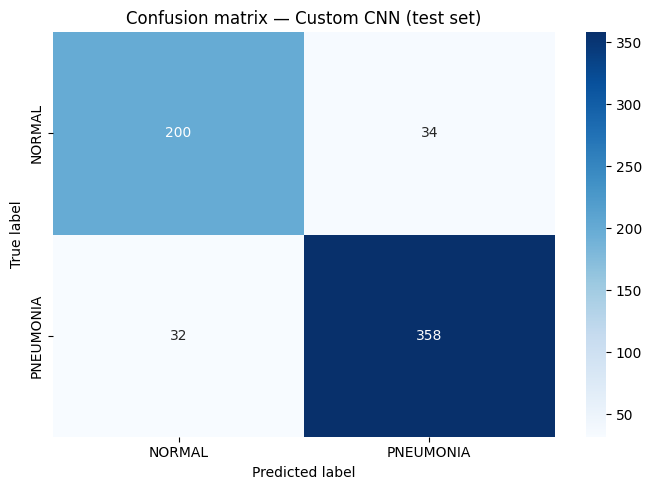


True  Negatives (NORMAL  → NORMAL)    : 200
False Positives (NORMAL  → PNEUMONIA) : 34  ← false alarms
False Negatives (PNEUMONIA → NORMAL)  : 32  ← missed cases (critical!)
True  Positives (PNEUMONIA → PNEUMONIA): 358

Sensitivity / Recall : 0.9179
Specificity          : 0.8547


In [27]:
# --- Step 3: Confusion matrix ---
# The most intuitive way to see what the model gets right and wrong
#
#                  Predicted
#              NORMAL  PNEUMONIA
# Actual NORMAL  [TN]    [FP]     ← FP = false alarm (annoying but safe)
# Actual PNEUMO  [FN]    [TP]     ← FN = missed case (dangerous!)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix — Custom CNN (test set)')
plt.tight_layout()
plt.show()

# Print the four numbers explicitly so they're easy to read
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (NORMAL  → NORMAL)    : {tn}")
print(f"False Positives (NORMAL  → PNEUMONIA) : {fp}  ← false alarms")
print(f"False Negatives (PNEUMONIA → NORMAL)  : {fn}  ← missed cases (critical!)")
print(f"True  Positives (PNEUMONIA → PNEUMONIA): {tp}")
print(f"\nSensitivity / Recall : {tp/(tp+fn):.4f}")
print(f"Specificity          : {tn/(tn+fp):.4f}")

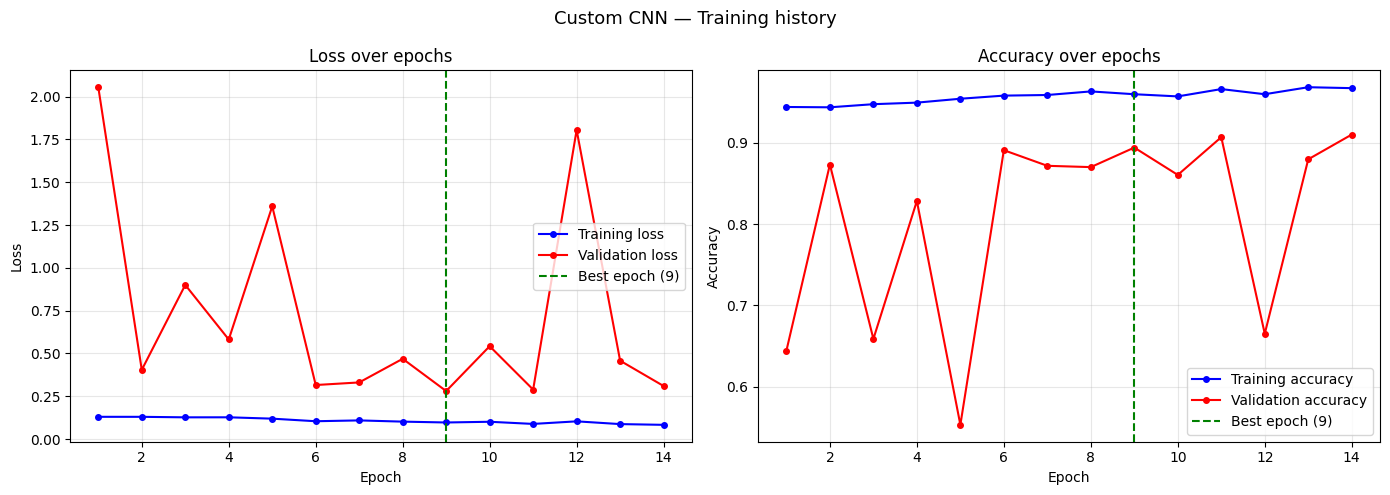

In [28]:
# ── Cell 15: Plot training curves ─────────────────────────────────────────────
# These two plots tell the story of your entire training run.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history.history['loss']) + 1)

# --- Plot 1: Loss ---
axes[0].plot(epochs_ran, history.history['loss'],
             'b-o', markersize=4, label='Training loss')
axes[0].plot(epochs_ran, history.history['val_loss'],
             'r-o', markersize=4, label='Validation loss')
axes[0].axvline(x=9, color='green', linestyle='--',
                linewidth=1.5, label='Best epoch (9)')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Accuracy ---
axes[1].plot(epochs_ran, history.history['accuracy'],
             'b-o', markersize=4, label='Training accuracy')
axes[1].plot(epochs_ran, history.history['val_accuracy'],
             'r-o', markersize=4, label='Validation accuracy')
axes[1].axvline(x=9, color='green', linestyle='--',
                linewidth=1.5, label='Best epoch (9)')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN — Training history', fontsize=13)
plt.tight_layout()
plt.show()

Saved: confusion_matrix.png
Saved: training_curves.png
Saved: custom_cnn_best.keras

All files saved! Folder structure ready.


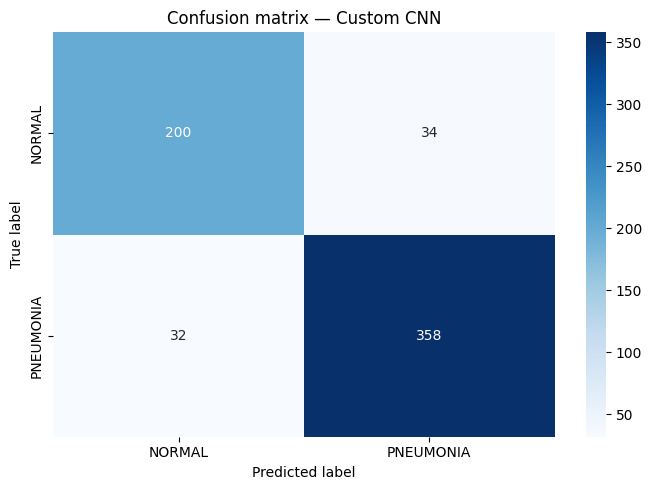

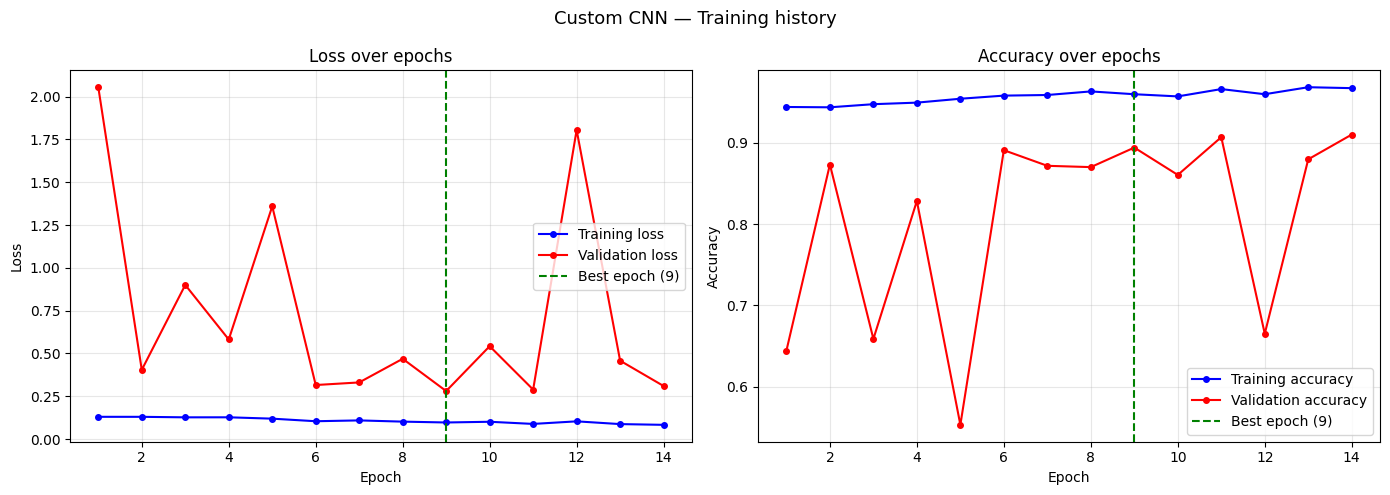

In [29]:
# ── Save all outputs into the correct folders ──────────────────────────────────
import os

# Create the folders
os.makedirs('/content/pneumonia-detection-cnn/notebooks', exist_ok=True)
os.makedirs('/content/pneumonia-detection-cnn/saved_models', exist_ok=True)
os.makedirs('/content/pneumonia-detection-cnn/outputs', exist_ok=True)

# Save confusion matrix plot
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_cm)
ax_cm.set_xlabel('Predicted label')
ax_cm.set_ylabel('True label')
ax_cm.set_title('Confusion matrix — Custom CNN')
fig_cm.tight_layout()
fig_cm.savefig('/content/pneumonia-detection-cnn/outputs/confusion_matrix.png', dpi=150)
print("Saved: confusion_matrix.png")

# Save training curves plot
fig_tc, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history.history['loss']) + 1)
axes[0].plot(epochs_ran, history.history['loss'], 'b-o', markersize=4, label='Training loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'r-o', markersize=4, label='Validation loss')
axes[0].axvline(x=9, color='green', linestyle='--', linewidth=1.5, label='Best epoch (9)')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_ran, history.history['accuracy'], 'b-o', markersize=4, label='Training accuracy')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'r-o', markersize=4, label='Validation accuracy')
axes[1].axvline(x=9, color='green', linestyle='--', linewidth=1.5, label='Best epoch (9)')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig_tc.suptitle('Custom CNN — Training history', fontsize=13)
fig_tc.tight_layout()
fig_tc.savefig('/content/pneumonia-detection-cnn/outputs/training_curves.png', dpi=150)
print("Saved: training_curves.png")

# Save the best model weights
import shutil
shutil.copy(
    '/content/saved_models/custom_cnn_best.keras',
    '/content/pneumonia-detection-cnn/saved_models/custom_cnn_best.keras'
)
print("Saved: custom_cnn_best.keras")

print("\nAll files saved! Folder structure ready.")